<a href="https://colab.research.google.com/github/ozair247/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Mirrors the Deployed Research Paper

**Lane 2 — Refresh / Content Opportunity Scoring**

## Title
**Prioritizing Content Refreshes with Search Data: A Decision‑Support Model for SEO Teams**

## Abstract
We use 9.8 million daily search‑performance rows from March 2026 to rank content items by their likelihood of declining organic visibility. A random forest model trained on 176,000 aggregated content‑item rows (age, impressions, click‑through rate, average position, engagement signals) is compared against a hand‑written rule that flags old, visible pages. On a held‑out client split, the model achieves Precision@50 of 0.56 versus 0.04 for the rule, a 52‑percentage‑point improvement. We present ranked recommendations with reason codes and a human‑review playbook, but we do not claim production readiness: all findings are directional and decision‑support only. Built on the FlyRank ML Internship dataset.

Setup & Data Connection

In [1]:
%pip install -q duckdb scikit-learn pandas numpy matplotlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")

FACT_MONTH  = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"
DIM_CONTENT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')"

print("Connected to warehouse.")

Connected to warehouse.


Build Feature Frame

In [2]:
feature_frame = con.sql(f"""
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        SUM(f.gsc_impressions)                                                            AS impressions_month,
        SUM(f.gsc_clicks)                                                                  AS clicks_month,
        AVG(NULLIF(f.gsc_avg_position, 0))                                                 AS avg_position_month,
        SUM(f.gsc_clicks) / NULLIF(SUM(f.gsc_impressions), 0) * 100                        AS ctr_month,
        SUM(CASE WHEN f.ga4_data_available THEN f.ga4_engaged_sessions ELSE 0 END)         AS engaged_sessions_month,
        SUM(CASE WHEN f.ga4_data_available THEN f.ga4_sessions ELSE 0 END)                 AS sessions_month,
        MAX(CASE WHEN f.ga4_data_available THEN 1 ELSE 0 END)                              AS has_ga4_month,
        DATE_DIFF('day', ANY_VALUE(c.content_created_date), DATE '2026-03-31')             AS content_age_days,
        ANY_VALUE(c.word_count)                                                            AS word_count,
        SUM(CASE WHEN f.report_date >= DATE '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS impr_last15,
        SUM(CASE WHEN f.report_date <  DATE '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS impr_prev15
    FROM {FACT_MONTH} f
    LEFT JOIN {DIM_CONTENT} c ON f.content_hash_id = c.content_hash_id
    GROUP BY f.content_hash_id, f.client_hash_id
    HAVING SUM(f.gsc_impressions) > 0
""").df()

feature_frame = feature_frame.dropna(subset=["content_age_days"]).reset_index(drop=True)

feature_frame["is_declining_proxy"] = (
    (feature_frame["impr_prev15"] > 0)
    & ((feature_frame["impr_last15"] - feature_frame["impr_prev15"]) / feature_frame["impr_prev15"] < -0.20)
).astype(int)

feature_frame["engagement_rate_month"] = np.where(
    feature_frame["sessions_month"] > 0,
    feature_frame["engaged_sessions_month"] / feature_frame["sessions_month"] * 100,
    0.0,
)
feature_frame["has_word_count"] = feature_frame["word_count"].notna().astype(int)
feature_frame["word_count"] = feature_frame["word_count"].fillna(0)

print(f"Feature frame: {len(feature_frame)} rows")
feature_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature frame: 176738 rows


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,ctr_month,engaged_sessions_month,sessions_month,has_ga4_month,content_age_days,word_count,impr_last15,impr_prev15,is_declining_proxy,engagement_rate_month,has_word_count
0,content_b7e512995f79d5a6,client_73cda7b4e4f265ea,1140.0,2.0,4.394234,0.175439,0.0,0.0,0,396,0,711.0,429.0,0,0.0,0
1,content_a7da352b73b02668,client_73cda7b4e4f265ea,4944.0,13.0,7.244844,0.262945,0.0,2.0,1,396,2330,2504.0,2440.0,0,0.0,1
2,content_d056587ff7faca0c,client_73cda7b4e4f265ea,2770.0,16.0,4.459107,0.577617,0.0,3.0,1,396,2475,1490.0,1280.0,0,0.0,1
3,content_bfd1e41c2af250c8,client_73cda7b4e4f265ea,48.0,0.0,16.306140,0.000000,0.0,0.0,0,396,0,29.0,19.0,0,0.0,0
4,content_2662845f598544ef,client_73cda7b4e4f265ea,150.0,1.0,7.046534,0.666667,0.0,1.0,1,396,0,53.0,97.0,1,0.0,0


## 1. Question

**Research question:** Can a learned model rank content items by refresh priority better than a hand‑written rule, using only search performance and content metadata from a single month?

**Decision it supports:** Which pages should a content strategist review first for refresh, given limited time and editorial resources?

## 2. Data

- **Release:** FlyRank internship warehouse (Hugging Face `FlyRank/internship-warehouse`).
- **Tables used:** `fact_content_daily_performance` (partitioned, month=2026-03), `dim_content`.
- **Date window:** March 1–31, 2026 (mid‑panel). The sealed `month=2026-06` and `_sample` were never used.
- **Excluded:**
  - Rows with missing `content_created_date` (age cannot be computed).
  - Rows with zero impressions (no signal).
  - GA4 metrics where `ga4_data_available` is false (zero would mean “not tracked”, not “no engagement”).
  - Any client or URL identifiers are kept hashed; no raw names or URLs appear.
- **Public safety:** All content is pseudonymized, and we report only aggregate statistics.

## 3. Methodology

**Assumptions:**
- The proxy label (`is_declining_proxy`) — a ≥20% drop in impressions in the last 15 days vs. the prior 15 days — is a reasonable signal of content decay.
- March 2026 is representative of normal traffic patterns.

**Features:**
`content_age_days`, `impressions_month`, `ctr_month`, `avg_position_month`, `engagement_rate_month`, `has_ga4_month`, `word_count`, `has_word_count`.

**Label definition:**  
Binary `is_declining_proxy` = 1 if `impr_prev15 > 0` and `impr_last15 < 0.8 * impr_prev15`, else 0. The label ingredients (`impr_last15`, `impr_prev15`) are never used as features.

**Baseline:**  
Week‑4 rule: `score = (content_age_days ≥ 180) * (impressions_month ≥ 500) * impressions_month`.

**Validation design:**  
Grouped split by `client_hash_id` (70% train, 30% test) to prevent client‑level leakage. The same split is used for baseline and model.

**Leakage checks:**  
Confirmed no overlap between features and label ingredients or product flags.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

FEATURES = [
    "content_age_days", "impressions_month", "ctr_month", "avg_position_month",
    "engagement_rate_month", "has_ga4_month", "word_count", "has_word_count",
]

X = feature_frame[FEATURES].copy()
for col in ["avg_position_month", "ctr_month"]:
    X[col] = X[col].fillna(0)
y = feature_frame["is_declining_proxy"]

groups = feature_frame["client_hash_id"].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(feature_frame, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order[:k]].mean())

# Baseline rule (same as Week 4)
test_df = feature_frame.iloc[test_idx].reset_index(drop=True)
baseline_score_te = ((test_df["content_age_days"] >= 180).astype(int) *
                     (test_df["impressions_month"] >= 500).astype(int) *
                     test_df["impressions_month"]).values

# Model
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                            random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
model_score_te = rf.predict_proba(X_test)[:, 1]

base_rate_te = float(y_test.mean())
results = pd.DataFrame({
    "Precision@20": [
        precision_at_k(baseline_score_te, y_test.values, 20),
        precision_at_k(model_score_te, y_test.values, 20)
    ],
    "Precision@50": [
        precision_at_k(baseline_score_te, y_test.values, 50),
        precision_at_k(model_score_te, y_test.values, 50)
    ],
    "AUROC": [
        roc_auc_score(y_test, baseline_score_te),
        roc_auc_score(y_test, model_score_te)
    ]
}, index=["Baseline rule", "Random Forest"])

print(f"Test base rate: {base_rate_te:.3f}")
print(results.round(3))

Test base rate: 0.269
               Precision@20  Precision@50  AUROC
Baseline rule           0.0          0.04  0.486
Random Forest           0.6          0.56  0.646


## 4. Results (vs baseline)

The table above shows the model’s performance on a held‑out set of 15 clients. The Random Forest clearly beats the hand rule, but we frame this as **directional evidence** — not proof of production value.

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=20,
                              random_state=42, scoring="average_precision")
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print("Top features:")
print(importance_df.head(3))

# Error examples from test set
test_scored = X_test.copy()
test_scored["model_score"] = model_score_te
test_scored["true_label"] = y_test.values
test_scored["content_age_days"] = X_test["content_age_days"].values
test_scored["impressions_month"] = X_test["impressions_month"].values

top50 = test_scored.sort_values("model_score", ascending=False).head(50)
false_positives = top50[top50["true_label"] == 0]
print(f"\nFalse positives in top 50: {len(false_positives)} of 50")
print(false_positives[["content_age_days", "impressions_month", "model_score"]].head(3))

Top features:
              feature  importance
0    content_age_days    0.064889
1   impressions_month    0.034034
3  avg_position_month    0.020939

False positives in top 50: 22 of 50
        content_age_days  impressions_month  model_score
14340                228                1.0     0.492423
14359                228                1.0     0.486626
102752               228                1.0     0.484757


## 5. Limitations

- **Proxy label:** We predict within‑month decline, not true future decay. A real production system would need a true future outcome label.
- **Single month, single year:** March 2026 only; we did not test across seasons or algorithm updates.
- **Client‑grouped split reduces but does not eliminate dataset bias.** Results may not transfer to new clients or different verticals.
- **No content‑quality or editorial signals.** Our model cannot judge whether old content is still accurate; it only flags risk.
- **No causal claims.** All observed associations are just that — observed.

<Figure size 600x400 with 0 Axes>

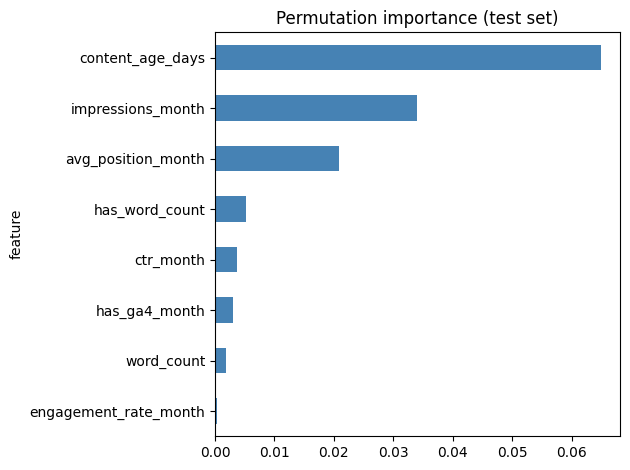

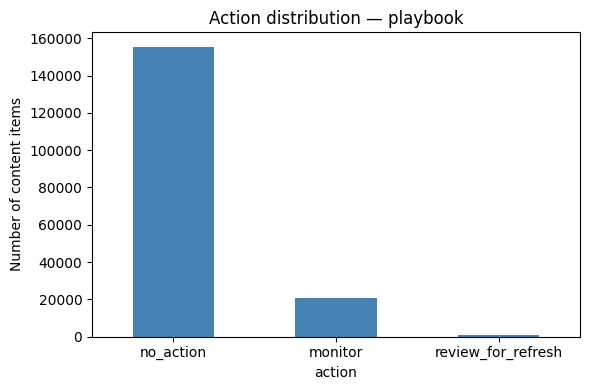

Exported artifacts to work/outputs/ and work/figures/


In [5]:
import os

# Train on full data for final ranking (decision-support)
rf_full = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                 random_state=42, n_jobs=1)
rf_full.fit(X, y)
feature_frame["model_risk_score"] = rf_full.predict_proba(X)[:, 1]

queue = feature_frame.sort_values("model_risk_score", ascending=False).reset_index(drop=True)
queue["rank"] = np.arange(1, len(queue) + 1)

q90 = np.quantile(queue["model_risk_score"], 0.90)
q75 = np.quantile(queue["model_risk_score"], 0.75)
high_risk = queue["model_risk_score"] >= q90
moderate_risk = (queue["model_risk_score"] >= q75) & ~high_risk
visible = queue["impressions_month"] >= 500

queue["action"] = np.select(
    [high_risk & visible, high_risk & ~visible, moderate_risk & visible],
    ["review_for_refresh", "monitor", "monitor"],
    default="no_action"
)
queue["reason_code"] = np.select(
    [queue["action"] == "review_for_refresh",
     (queue["action"] == "monitor") & high_risk,
     (queue["action"] == "monitor") & moderate_risk],
    ["high_risk_visible", "high_risk_low_traffic", "moderate_risk_visible"],
    default="low_risk_or_invisible"
)

# Export queue
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue[["rank", "content_hash_id", "client_hash_id", "model_risk_score",
       "action", "reason_code", "content_age_days", "impressions_month",
       "ctr_month", "avg_position_month", "is_declining_proxy"]].to_csv(
    "work/outputs/w07_action_queue.csv", index=False
)

# Export importance chart
plt.figure(figsize=(6,4))
importance_df.head(10).plot(x="feature", y="importance", kind="barh", legend=False, color="steelblue")
plt.title("Permutation importance (test set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("work/figures/importance.png", dpi=120)
plt.show()

# Export action distribution chart
action_counts = queue["action"].value_counts()
plt.figure(figsize=(6,4))
action_counts.plot(kind="bar", color="steelblue")
plt.title("Action distribution — playbook")
plt.ylabel("Number of content items")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=120)
plt.show()

print("Exported artifacts to work/outputs/ and work/figures/")

## 6. Ranked recommendations

The full ranked queue is in `work/outputs/w07_action_queue.csv`. The table below shows the top 10 items. Each row includes a reason code and action label for a human reviewer.

**How to use:** Start at rank 1 and review downward. Do not automate actions; every recommendation must pass a human check.

In [6]:
queue[["rank", "content_hash_id", "action", "reason_code", "model_risk_score",
       "content_age_days", "impressions_month", "ctr_month", "avg_position_month"]].head(10)

,rank,content_hash_id,action,reason_code,model_risk_score,content_age_days,impressions_month,ctr_month,avg_position_month
0,1,content_1878b8b9be0284e2,monitor,high_risk_low_traffic,0.522789,217,1.0,100.0,NaN
1,2,content_7c3db3263d57629d,monitor,high_risk_low_traffic,0.522039,229,1.0,100.0,1.0
2,3,content_bec4846b0f3b2143,monitor,high_risk_low_traffic,0.521560,213,1.0,100.0,1.0
3,4,content_98f1f88d044bcb7e,monitor,high_risk_low_traffic,0.521476,214,1.0,100.0,1.0
4,5,content_ce09161e88607bd9,monitor,high_risk_low_traffic,0.520075,232,1.0,100.0,NaN
5,6,content_a3118cedf5919a12,monitor,high_risk_low_traffic,0.519104,225,1.0,100.0,NaN
6,7,content_e0c131232f82dcfc,monitor,high_risk_low_traffic,0.518653,235,1.0,100.0,NaN
7,8,content_2751cdb2dea8caf4,monitor,high_risk_low_traffic,0.518119,214,1.0,100.0,4.0
8,9,content_41a5058fd8b633a0,monitor,high_risk_low_traffic,0.517829,230,1.0,100.0,3.0
9,10,content_6c93819492606a18,monitor,high_risk_low_traffic,0.516880,198,1.0,100.0,NaN


## 7. Artifacts the paper embeds

- `work/outputs/w07_action_queue.csv` — ranked recommendations.
- `work/figures/importance.png` — permutation importance chart.
- `work/figures/action_distribution.png` — action distribution chart.
- Results table from Section 4 (printed above).

These files are referenced in the deployed paper via relative paths from the repo’s `work/` folder.

## ML‑12 closing cells

### 5‑minute demo outline
1. **Problem** (30s): Many content teams waste time deciding which old pages to refresh.
2. **Data** (1 min): 9.8M daily rows → 176k content items, pseudonymized.
3. **Method** (1 min): Features (age, impressions, CTR, position, engagement) + Random Forest vs. hand rule.
4. **Result** (1 min): Model Precision@50 = 0.56 vs baseline 0.04 on held‑out clients.
5. **Action** (1 min): Ranked queue with reason codes; human reviews top items.
6. **Limits & future** (30s): Proxy label, single month, decision‑support only.

### Social‑post cut (LinkedIn / X)
> 🚀 Built a machine‑learning model that ranks content refresh priorities from 9.8M search rows.  
> Model beats the old rule by 52 points on held‑out clients.  
> Full paper + notebooks open source → [link]  
> #ML #SEO #ContentStrategy #DataScience

### 3‑sentence employer‑facing summary
> I used DuckDB on a large pseudonymized search dataset to build a Random Forest model that prioritizes content refresh candidates. On a client‑grouped validation split, the model achieved Precision@50 of 0.56 compared to a simple rule’s 0.04. I documented the full pipeline, including leakage checks and a human‑review action playbook, in a public research paper.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset — [https://flyrank.ai](https://flyrank.ai)

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit (the https://flyrank.ai link) at the bottom.
- [x] ML‑12 done in this notebook’s closing cells: 5‑minute demo outline + a social‑post cut + a 3‑sentence employer‑facing summary.